<h1 style="color: #1E90FF; font-size: 2.5em; font-weight: bold;">
    FIFA 21 Player Market Value Prediction
</h1>


### <font color='#1E90FF'>**Table of Contents**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Import libraries and Set up](#2)
- [3. Load Data](#3)
- [4. MetaData](#4)
- [5. Exploratory Data Analysis](#5)
    - [5.1. Check Data Types](#5_1)
    - [5.2. Check Missing Values](#5_2)
    - [5.3. Check for Duplicates](#5_3)
    - [5.4. Check Unique Values](#5_4)
- [6. Data Preparation](#6)
    - [6.1. Data Preprocessing](#6_1)
        - [6.1.1. Removing Useless Columns](#6_1_1)
        - [6.1.2. Renaming Columns](#6_1_2)
        - [6.1.3. Removing Special Characters and Typecasting](#6_1_3)
        - [6.1.4. Convert Features to Correct Data Type](#6_1_4)
- [7. EDA after Cleaning](#7)
- [8. Feature Engineering](#8)

<a class="anchor" id="1">

# **1. Project Overview**

[Back to TOC](#toc)
</a>

**TO DO**: Introduzir uma intro do projeto 


<a class="anchor" id="2">

# **2. Import libraries and Set up**

[Back to TOC](#toc)
</a>

In [1]:
!pip install pyspark plotly "pandas>=2.2.0" "nbformat>=4.2.0"

In [2]:
# Install Java 17 (Required for Spark)
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless
!java -version

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://download.docker.com/linux/ubuntu noble InRelease                 
Hit:3 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease          
Hit:4 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease  
Hit:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:6 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-security InRelease 
Hit:7 https://security.ubuntu.com/ubuntu noble-security InRelease              
Hit:8 https://archive.ubuntu.com/ubuntu noble InRelease                        
Hit:9 https://archive.ubuntu.com/ubuntu noble-updates InRelease                
Hit:10 https://archive.ubuntu.com/ubuntu noble-backports InRelease             
Hit:11 http://deb.wakemeops.com/wakemeops stable InRelease              
Hit:12 https://packages.cloud.google.com/apt cloud-sdk InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree...

In [3]:
import sqlite3
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, split, when, trim, size,regexp_extract, to_date, year, countDistinct

# Set JAVA_HOME and initialize Spark Session with specific configurations
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"


spark = SparkSession.builder \
        .master("local[4]") \
        .appName("PySpark DataFrames API") \
        .config("spark.executor.memory", "4g") \
        .config("spark.driver.memory", "2g") \
        .getOrCreate()

print("Spark Session configured and ready!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/01 12:02:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/01 12:02:23 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark Session configured and ready!


<a class="anchor" id="3">

# **3. Load Data**

[Back to TOC](#toc)
</a>

In [4]:
df = spark.read.csv('./fifa21 raw data v2.csv', header=True, multiLine=True)

In [5]:
#df = spark.read.csv('/teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/FIFA/fifa21 raw data v2.csv', header=True, multiLine=True)

The .csv file contains random placed strings (") and "\n". Spark tries to read it but it counts as a new line in wrongfull places.

To correct it, when reading the .csv we added the parameter `multiline = True`.

In [6]:
# Create an alias and cache the DataFrame for downstream transformations
fifa = df.cache()

26/06/01 12:02:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


The method .cache() will store the fifa dataset in memory, improving performance by avoiding reloading and recomputing in Spark, allowing it to be accessed across multiple transformations and actions. 

In [7]:
#set employee_id as index ??? isto nao é possivel com spark, só estamos a por em formato string 
fifa = fifa.withColumn("ID", col("ID").cast("string"))

<a class="anchor" id="4">

# **4. MetaData**

[Back to TOC](#toc)
</a>

#### Player Identity & Basics
* **ID**: The unique identification number assigned to each player in the database.
* **Name**: The short version of the player's name (e.g., L. Messi).
* **LongName**: The full name of the player.
* **photoUrl**: The web link to the player's profile picture.
* **playerUrl**: The web link to the player's full profile on SoFIFA.
* **Nationality**: The country the player is from.
* **Age**: The player's current age.
* **Club**: The team the player is currently playing for.
* **Contract**: The years remaining on the player's current contract or the contract type.
* **Positions**: All the positions the player is capable of playing.
* **Height**: The player's height (usually in cm).
* **Weight**: The player's weight (usually in kg).
* **Preferred Foot**: The foot (Left or Right) the player prefers to use.
* **Joined**: The exact date the player signed with his current club.
* **Loan Date End**: The date a player's loan period ends (if applicable).

#### Performance Ratings
* **OVA (Overall Rating)**: The general skill level of the player (0-99).
* **POT (Potential)**: The maximum rating the player can reach in his career.
* **BOV (Best Overall)**: The rating the player has in his best specific position.
* **Best Position**: The specific role where the player performs at his highest level.

#### Financial Information
* **Value**: The estimated market value of the player in Euros.
* **Wage**: The weekly salary the player earns at his club.
* **Release Clause**: The amount another club must pay to buy the player instantly.

#### Attacking Attributes
* **Attacking**: The total sum of points of all attacking categories.
* **Crossing**: Accuracy of crosses into the penalty area.
* **Finishing**: Ability to score goals when inside the box.
* **Heading Accuracy**: Accuracy of headers for passes or shots.
* **Short Passing**: Accuracy of short, ground-level passes.
* **Volleys**: Ability to strike the ball while it is in the air.

#### Skill Attributes
* **Skill**: The total sum of points of all technical skill categories.
* **Dribbling**: Ability to control the ball while moving at speed.
* **Curve**: Ability to bend the ball's trajectory (e.g., on free kicks).
* **FK Accuracy**: Accuracy when taking direct free kicks.
* **Long Passing**: Accuracy of long-distance or lobbed passes.
* **Ball Control**: Ability to control the ball instantly when receiving it.

#### Movement Attributes
* **Movement**: The total sum of points of all movement categories.
* **Acceleration**: How quickly a player reaches top speed.
* **Sprint Speed**: The maximum speed the player can reach.
* **Agility**: How quickly a player can change direction.
* **Reactions**: How fast a player responds to a situation happening around them.
* **Balance**: Ability to stay on his feet under physical pressure.

#### Power Attributes
* **Power**: The total sum of points of all physical power categories.
* **Shot Power**: How hard the player can kick the ball.
* **Jumping**: How high the player can jump for headers.
* **Stamina**: How long the player can run before getting tired.
* **Strength**: Physical power to push off opponents.
* **Long Shots**: Ability to score from outside the penalty area.

#### Mentality Attributes
* **Mentality**: The total sum of points of all mental categories.
* **Aggression**: The frequency and intensity of physical challenges and tackles.
* **Interceptions**: Ability to read the game and cut off opponent passes.
* **Positioning**: Ability to find open space on the field.
* **Vision**: Ability to see teammates' runs and execute difficult passes.
* **Penalties**: Accuracy and composure when taking penalty kicks.
* **Composure**: Ability to perform well under pressure from defenders.

#### Defending Attributes
* **Defending**: The total sum of points of all defensive categories.
* **Marking**: Ability to stay close to and track an opponent.
* **Standing Tackle**: Ability to take the ball away while standing.
* **Sliding Tackle**: Ability to take the ball away using a slide.

#### Goalkeeping Attributes
* **Goalkeeping**: The total sum of points of all goalkeeper skills.
* **GK Diving**: Ability to reach for the ball while jumping.
* **GK Handling**: Ability to catch and hold onto the ball.
* **GK Kicking**: Accuracy and distance of goal kicks.
* **GK Positioning**: Ability to stand in the right place to cover the goal.
* **GK Reflexes**: How fast the keeper reacts to close-range shots.

#### Playing Style & Summary Stats
* **Total Stats**: The sum of all individual attribute points of the player.
* **Base Stats**: The sum of the six main face-card attributes (Pace, Shooting, Passing, Dribbling, Defense, Physical).
* **W/F (Weak Foot)**: Performance with the non-dominant foot (1-5 stars).
* **SM (Skill Moves)**: Ability to perform dribbling tricks (1-5 stars).
* **A/W (Attacking Work Rate)**: Effort level in attack (Low/Medium/High).
* **D/W (Defensive Work Rate)**: Effort level in defense (Low/Medium/High).
* **IR (International Reputation)**: Global fame level (1-5 stars).
* **PAC (Pace)**: Overall speed rating.
* **SHO (Shooting)**: Overall scoring rating.
* **PAS (Passing)**: Overall playmaking rating.
* **DRI (Dribbling)**: Overall ball-carrying rating.
* **DEF (Defending)**: Overall defensive rating.
* **PHY (Physical)**: Overall physical presence rating.

#### Other
* **Hits**: Number of views or searches for the player on the platform.

<a class="anchor" id="5">

# **5. Exploratory Data Analysis**

[Back to TOC](#toc)
</a>

In [8]:
n_rows = fifa.count()
n_cols = len(fifa.columns)

print(f"Rows: {n_rows}")
print(f"Columns: {n_cols}")

Rows: 18979
Columns: 77


In [9]:
fifa.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- LongName: string (nullable = true)
 |-- photoUrl: string (nullable = true)
 |-- playerUrl: string (nullable = true)
 |-- Nationality: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- ↓OVA: string (nullable = true)
 |-- POT: string (nullable = true)
 |-- Club: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- Positions: string (nullable = true)
 |-- Height: string (nullable = true)
 |-- Weight: string (nullable = true)
 |-- Preferred Foot: string (nullable = true)
 |-- BOV: string (nullable = true)
 |-- Best Position: string (nullable = true)
 |-- Joined: string (nullable = true)
 |-- Loan Date End: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- Wage: string (nullable = true)
 |-- Release Clause: string (nullable = true)
 |-- Attacking: string (nullable = true)
 |-- Crossing: string (nullable = true)
 |-- Finishing: string (nullable = true)
 |-- Heading

In [10]:
fifa.show(20)

+------+-----------------+--------------------+--------------------+--------------------+-----------+---+----+---+--------------------+-----------+----------+------+------+--------------+---+-------------+------------+-------------+-------+-----+--------------+---------+--------+---------+----------------+-------------+-------+-----+---------+-----+-----------+------------+------------+--------+------------+------------+-------+---------+-------+-----+----------+-------+-------+--------+----------+---------+----------+-------------+-----------+------+---------+---------+---------+-------+---------------+--------------+-----------+---------+-----------+----------+--------------+-----------+-----------+----------+---+---+------+------+---+---+---+---+---+---+---+----+
|    ID|             Name|            LongName|            photoUrl|           playerUrl|Nationality|Age|↓OVA|POT|                Club|   Contract| Positions|Height|Weight|Preferred Foot|BOV|Best Position|      Joined|Loan 

By analysing some rows, we can already see some inconsistencies:

- `Club`: in the beggining of every cell in this column, there are a lot of "\n" which correspond to spaces which have no meaning in this case. We'll remove it.

- `Contract`: In this feature, there are two dates separated by a "~" for each contract which we assume that it corresponds to the beggining and end date of every player in said club. We will separate the column in two, one for the year of entering the club and other for termination of contract.

- `Positions`: It would be interesting to have a new column based on this one to count the number of positions each player has since some of them has more than one position.

- `Height and Weight`: in each of the columns there are more than one measurement systems, cm and inches or kg and lbs. This will all be converted to the european measurements: cm and kg.

- `Loan Date End`: it has a lot of "NULL". We have to check if it's missing values or strings with "NULL".

- `Value, Wage and Release Clause`: has "$" sign, "K" for thousands and "M" for million. We'll turn this into only numeric column.

- `W/F, SM and IR`: these features have stars after every number because it was extracted from the website of fifa. They will be removed.

Since we have so many columns, we will probably drop some if they have redundant information.

In [11]:
numeric_cols = [
    col_name
    for col_name, dtype in fifa.dtypes
    if dtype in ['int', 'bigint', 'double', 'float', 'long', 'decimal']
]

In [12]:
# in this phase, since all features are still categorized as strings, we will analyse all features, even non numeric
fifa.summary().show()

26/06/01 12:02:38 WARN DAGScheduler: Broadcasting large task binary with size 1141.8 KiB


+-------+------------------+-----------+--------------------+--------------------+--------------------+-----------+------------------+-----------------+------------------+--------------------+--------------------+---------+------+------+--------------+-----------------+-------------+-----------+-------------+-----+-----+--------------+------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-------

Since some players have "No Club", we can analyse inconsistencies in `Contract` or if they are interesting for our analysis or not. Also in name fields some players have special carachters. It may be because some players may be from different countries with letters that don't belong to our alphabet.

In [13]:
# show the distribution of values in "Value" for players who have "No Club"
fifa.filter(col("Club") == "No Club").select("Value", "Contract").distinct().show()

+-----+--------+
|Value|Contract|
+-----+--------+
|   €0|    Free|
+-----+--------+



All players without Club have no current value and contract is "Free" as expected

<a class="anchor" id="5_1">

## **5.1. Check Data Types**

[Back to TOC](#toc)
</a>

In [14]:
for col_name, dtype in df.dtypes:
    print(f"{col_name}: {dtype}")

ID: string
Name: string
LongName: string
photoUrl: string
playerUrl: string
Nationality: string
Age: string
↓OVA: string
POT: string
Club: string
Contract: string
Positions: string
Height: string
Weight: string
Preferred Foot: string
BOV: string
Best Position: string
Joined: string
Loan Date End: string
Value: string
Wage: string
Release Clause: string
Attacking: string
Crossing: string
Finishing: string
Heading Accuracy: string
Short Passing: string
Volleys: string
Skill: string
Dribbling: string
Curve: string
FK Accuracy: string
Long Passing: string
Ball Control: string
Movement: string
Acceleration: string
Sprint Speed: string
Agility: string
Reactions: string
Balance: string
Power: string
Shot Power: string
Jumping: string
Stamina: string
Strength: string
Long Shots: string
Mentality: string
Aggression: string
Interceptions: string
Positioning: string
Vision: string
Penalties: string
Composure: string
Defending: string
Marking: string
Standing Tackle: string
Sliding Tackle: string


All features are strings, even the statistic fields which are supposed to be numeric. This will be changed in the next steps to allow for proper analysis and visualization.

<a class="anchor" id="5_2">

## **5.2.  Check Missing Values**

[Back to TOC](#toc)
</a>

In [15]:
# change "NULL" cells to actual null values
fifa = fifa.replace("NULL", None)

In [16]:
from pyspark.sql import functions as F

fifa.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in fifa.columns
]).show()

+---+----+--------+--------+---------+-----------+---+----+---+----+--------+---------+------+------+--------------+---+-------------+------+-------------+-----+----+--------------+---------+--------+---------+----------------+-------------+-------+-----+---------+-----+-----------+------------+------------+--------+------------+------------+-------+---------+-------+-----+----------+-------+-------+--------+----------+---------+----------+-------------+-----------+------+---------+---------+---------+-------+---------------+--------------+-----------+---------+-----------+----------+--------------+-----------+-----------+----------+---+---+---+---+---+---+---+---+---+---+---+----+
| ID|Name|LongName|photoUrl|playerUrl|Nationality|Age|↓OVA|POT|Club|Contract|Positions|Height|Weight|Preferred Foot|BOV|Best Position|Joined|Loan Date End|Value|Wage|Release Clause|Attacking|Crossing|Finishing|Heading Accuracy|Short Passing|Volleys|Skill|Dribbling|Curve|FK Accuracy|Long Passing|Ball Control|

In [17]:
missing_pct = fifa.select([
    (F.count(F.when(F.col(c).isNull(), c)) / F.count("*") * 100).alias(c)
    for c in fifa.columns
])

missing_pct.show(truncate=False)

+---+----+--------+--------+---------+-----------+---+----+---+----+--------+---------+------+------+--------------+---+-------------+------+----------------+-----+----+--------------+---------+--------+---------+----------------+-------------+-------+-----+---------+-----+-----------+------------+------------+--------+------------+------------+-------+---------+-------+-----+----------+-------+-------+--------+----------+---------+----------+-------------+-----------+------+---------+---------+---------+-------+---------------+--------------+-----------+---------+-----------+----------+--------------+-----------+-----------+----------+---+---+---+---+---+---+---+---+---+---+---+------------------+
|ID |Name|LongName|photoUrl|playerUrl|Nationality|Age|↓OVA|POT|Club|Contract|Positions|Height|Weight|Preferred Foot|BOV|Best Position|Joined|Loan Date End   |Value|Wage|Release Clause|Attacking|Crossing|Finishing|Heading Accuracy|Short Passing|Volleys|Skill|Dribbling|Curve|FK Accuracy|Long P

Here we confirm that `Loan Date End` and `Hits` have missing values, 17.966 and 2.595, respectively, which corresponds to 94.66% and 13.67%.

The number of missing values in `Loan Date End` is normal since, a player being loaned to another club isn't so common.

The missing values in `Hits` is also understandeble since it represents the number of visits to the player page in the plaform. Less known players may have never been visited :(

<a class="anchor" id="5_3">

## **5.3.  Check for Duplicates**

[Back to TOC](#toc)
</a>

In [18]:
total_rows = fifa.count()
unique_rows = fifa.dropDuplicates().count()

print("Duplicated rows:", total_rows - unique_rows)

Duplicated rows: 0


There are no duplicates. We are going to check Name duplicates and other specific ones that wouldn't make sense.

In [19]:
fifa.groupBy("LongName") \
    .count() \
    .filter(F.col("count") > 1) \
    .show()

+--------------------+-----+
|            LongName|count|
+--------------------+-----+
|       Michael Smith|    2|
|           Joe Riley|    2|
|      José Hernández|    2|
|     Richard Sánchez|    2|
|        Juan Ramírez|    2|
|          Diego Sosa|    2|
|        Jae Sung Lee|    2|
|       Luis Cárdenas|    2|
|     Alejandro Gómez|    2|
|            Shuai Li|    2|
|Matías de los Santos|    2|
|    Ignacio González|    2|
|  Sebastián Martínez|    2|
|        Adama Traoré|    3|
|        Riku Matsuda|    2|
|   Mathias Jørgensen|    2|
|     Leonardo Castro|    2|
|          Matt Smith|    2|
|         Tae Hee Lee|    2|
|         Greg Taylor|    2|
+--------------------+-----+
only showing top 20 rows


In [20]:
fifa.groupBy("LongName", "Age") \
    .count() \
    .filter(F.col("count") > 1) \
    .show()

+--------------+---+-----+
|      LongName|Age|count|
+--------------+---+-----+
|José Hernández| 23|    2|
|     Peng Wang| 27|    2|
|  Adama Traoré| 25|    2|
|   Alan Medina| 22|    2|
|  Ryan Edwards| 26|    2|
|   Scott Brown| 35|    2|
|    Liam Kelly| 24|    2|
+--------------+---+-----+



In [21]:
fifa.groupBy("LongName", "Age", "Height", "Weight") \
    .count() \
    .filter(F.col("count") > 1) \
    .show()

+--------+---+------+------+-----+
|LongName|Age|Height|Weight|count|
+--------+---+------+------+-----+
+--------+---+------+------+-----+



With this analysis we conclude that some players have the same name, however, they don't correspond to the same players, they have different ages, weights and height.

<a class="anchor" id="5_4">

## **5.4. Check Unique Values**

[Back to TOC](#toc)
</a>

In [22]:
fifa.columns

['ID',
 'Name',
 'LongName',
 'photoUrl',
 'playerUrl',
 'Nationality',
 'Age',
 '↓OVA',
 'POT',
 'Club',
 'Contract',
 'Positions',
 'Height',
 'Weight',
 'Preferred Foot',
 'BOV',
 'Best Position',
 'Joined',
 'Loan Date End',
 'Value',
 'Wage',
 'Release Clause',
 'Attacking',
 'Crossing',
 'Finishing',
 'Heading Accuracy',
 'Short Passing',
 'Volleys',
 'Skill',
 'Dribbling',
 'Curve',
 'FK Accuracy',
 'Long Passing',
 'Ball Control',
 'Movement',
 'Acceleration',
 'Sprint Speed',
 'Agility',
 'Reactions',
 'Balance',
 'Power',
 'Shot Power',
 'Jumping',
 'Stamina',
 'Strength',
 'Long Shots',
 'Mentality',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'Defending',
 'Marking',
 'Standing Tackle',
 'Sliding Tackle',
 'Goalkeeping',
 'GK Diving',
 'GK Handling',
 'GK Kicking',
 'GK Positioning',
 'GK Reflexes',
 'Total Stats',
 'Base Stats',
 'W/F',
 'SM',
 'A/W',
 'D/W',
 'IR',
 'PAC',
 'SHO',
 'PAS',
 'DRI',
 'DEF',
 'PHY',
 'Hits']

In [23]:
def show_unique_values(df, max_values=10):
    """
    Displays the unique values of each column in the DataFrame.
    For columns with many unique values, limits the output to 'max_values'.
    
    Parameters:
        df (DataFrame): Input Spark DataFrame.
        max_values (int): Maximum number of unique values to display per column.
    """
    for column in df.columns:
        print(f"Unique values for column: {column}")
        
        # Count distinct values (wraps the column name in backticks to handle special characters)
        unique_count = df.agg(countDistinct(col(f"`{column}`")).alias("unique_count")) \
                         .collect()[0]["unique_count"]
        print(f"Total unique values: {unique_count}")
        
        # Get a sample of distinct values
        rows = df.select(col(f"`{column}`")).distinct().limit(max_values).collect()
        unique_values = [row[0] for row in rows]   # using index 0 is safer than row[column]
        
        print(f"Sample of unique values (up to {max_values}): {unique_values}")
        print("-" * 40)

show_unique_values(fifa, max_values=10)

Unique values for column: ID


Total unique values: 18979
Sample of unique values (up to 10): ['205069', '193105', '203605', '234035', '189280', '205346', '188942', '247030', '241854', '222457']
----------------------------------------
Unique values for column: Name
Total unique values: 17920
Sample of unique values (up to 10): ['M. Politano', 'A. Saint-Maximin', 'G. Xhaka', 'A. Izzo', 'Postigo', 'G. Schennikov', 'F. Jara', 'R. Assalé', 'C. Adams', 'J. Castelletto']
----------------------------------------
Unique values for column: LongName
Total unique values: 18852
Sample of unique values (up to 10): ['Kenny Lala', 'Víctor Machín Pérez', 'Bouna Sarr', 'Lucas Castro', 'Anwar El Ghazi', 'Rúben Afonso Borges Semedo', 'Jawad El Yamiq', 'Jacob Bruun Larsen', 'Gérson Adriano Damesio Figueiras', 'Ezequiel Unsain']
----------------------------------------
Unique values for column: photoUrl
Total unique values: 18979
Sample of unique values (up to 10): ['https://cdn.sofifa.com/players/209/331/21_60.png', 'https://cdn.sofif

In [24]:
categorical_cols = [
    c for c, t in fifa.dtypes
    if t == "string"
]

for c in categorical_cols:
    print(f"\nValue counts for: {c}")

    fifa.groupBy(c) \
        .count() \
        .orderBy(F.desc("count")) \
        .show(10, truncate=False)


Value counts for: ID


+------+-----+
|ID    |count|
+------+-----+
|205069|1    |
|193105|1    |
|203605|1    |
|234035|1    |
|189280|1    |
|205346|1    |
|188942|1    |
|247030|1    |
|241854|1    |
|222457|1    |
+------+-----+
only showing top 10 rows

Value counts for: Name
+------------+-----+
|Name        |count|
+------------+-----+
|J. Rodríguez|13   |
|Paulinho    |8    |
|A. González |7    |
|J. García   |7    |
|R. Fernández|7    |
|M. Smith    |7    |
|J. Jones    |7    |
|J. González |7    |
|J. Williams |6    |
|J. Rojas    |6    |
+------------+-----+
only showing top 10 rows

Value counts for: LongName
+--------------------+-----+
|LongName            |count|
+--------------------+-----+
|Adama Traoré        |3    |
|Nicolás González    |3    |
|Danny Rose          |3    |
|Peng Wang           |3    |
|Diego Rodríguez     |3    |
|Liam Kelly          |3    |
|Michael Smith       |2    |
|Matías de los Santos|2    |
|Joe Riley           |2    |
|José Hernández      |2    |
+----------------

<a class="anchor" id="6">

# **6.  Data Preparation**

[Back to TOC](#toc)
</a>

<a class="anchor" id="6_1">

## **6.1. Data Preprocessing**

[Back to TOC](#toc)
</a>

<a class="anchor" id="6_1_1">

### **6.1.1. Removing Useless Columns**

[Back to TOC](#toc)
</a>

Firstly, we will be dropping the columns `photoUrl` and `playerUrl` as it gives us no usefull information.

In [25]:
fifa = fifa.drop("Name","photoUrl", "playerUrl")

<a class="anchor" id="6_1_2">

### **6.1.2. Renaming Columns**

[Back to TOC](#toc)
</a>

Here, after droping the column `Name`, we rename the column `LongName` to Name and also rename the `OVA` one.

In [26]:
fifa = fifa.withColumnRenamed("LongName", "Name")
fifa = fifa.withColumnRenamed("↓OVA", "OVA")

Special carachters in Spark are not the optimum so, for all spaces and special symbols we'll replace by an "_".

In [27]:
rename_map = {
    "Heading Accuracy": "Heading_Accuracy",
    "Short Passing": "Short_Passing",
    "Ball Control": "Ball_Control",
    "Sprint Speed": "Sprint_Speed",
    "Shot Power": "Shot_Power",
    "Long Shots": "Long_Shots",
    "Long Passing": "Long_Passing",
    "FK Accuracy": "FK_Accuracy",
    "Standing Tackle": "Standing_Tackle",
    "Sliding Tackle": "Sliding_Tackle",
    "GK Diving": "GK_Diving",
    "GK Handling": "GK_Handling",
    "GK Kicking": "GK_Kicking",
    "GK Positioning": "GK_Positioning",
    "GK Reflexes": "GK_Reflexes",
    "Total Stats": "Total_Stats",
    "Base Stats": "Base_Stats",
    "Preferred Foot": "Preferred_Foot",
    "Best Position": "Best_Position",
    "Release Clause": "Release_Clause",
    "W/F": "Weak_Foot",
    "SM": "Skill_Moves",
    "A/W": "Attack_Workrate",
    "D/W": "Defense_Workrate",
    "IR": "Intl_Reputation",
}
for old, new in rename_map.items():
    fifa = fifa.withColumnRenamed(old, new)

<a class="anchor" id="6_1_3">

### **6.1.3. Removing Special Characters and Typecasting**

[Back to TOC](#toc)
</a>

The `Club` column has invalid characters such as \n, here we will remove them.

In [28]:
fifa = fifa.withColumn("Club", trim(regexp_replace(col("Club"), r"[\n]", "")))

In this step, we are normalizing all `Height` values to the metric system (cm) and converting the data type from string to integer.

In [29]:
fifa = fifa.withColumn("Height", 
    when(col("Height").contains("'"), 
        (split(col("Height"), "'")[0].cast("float") * 30.48) + 
        (regexp_replace(split(col("Height"), "'")[1], '"', "").cast("float") * 2.54)
    ).otherwise(regexp_replace(col("Height"), "cm", "").cast("float"))
).withColumn("Height", col("Height").cast("int"))

We will do the same for the `Weight` values.

In [30]:
fifa = fifa.withColumn("Weight", 
    when(col("Weight").contains("lbs"), 
        (regexp_replace(col("Weight"), "lbs", "").cast("float") * 0.453592)
    ).otherwise(regexp_replace(col("Weight"), "kg", "").cast("float"))
).withColumn("Weight", col("Weight").cast("int"))

Columns like `Value`, `Wage`, and `Hits` contain symbols ('€') and abbreviations ('M', 'K'). We apply a custom `parse_multipliers` function to clean the strings, calculate the final numerical values, and convert them to integers.

In [31]:
def parse_multipliers(column_name):
    return when(col(column_name).contains("M"), 
                (regexp_replace(col(column_name), "[€|M]", "").cast("float") * 1000000)) \
          .when(col(column_name).contains("K"), 
                (regexp_replace(col(column_name), "[€|K]", "").cast("float") * 1000)) \
          .otherwise(regexp_replace(col(column_name), "[€]", "").cast("float"))

for c in ["Value", "Wage", "Release_Clause", "Hits"]:
    fifa = fifa.withColumn(c, parse_multipliers(c).cast("int"))

<a class="anchor" id="6_1_4">

### **6.1.4. Convert Features to Correct Data Type**

[Back to TOC](#toc)
</a>

Here we will convert all the simple numeric features from string to integer.

In [32]:
int_cols = [
    'ID', 'Age', 'OVA', 'POT', 'BOV', 'Attacking', 'Crossing', 'Finishing', 'Heading_Accuracy', 'Short_Passing', 'Volleys',
    'Skill', 'Dribbling', 'Curve', 'FK_Accuracy', 'Long_Passing', 'Ball_Control', 'Movement', 'Acceleration', 'Sprint_Speed',
    'Agility', 'Reactions', 'Balance', 'Power', 'Shot_Power', 'Jumping', 'Stamina', 'Strength', 'Long_Shots',
    'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending', 'Marking',
    'Standing_Tackle', 'Sliding_Tackle', 'Goalkeeping', 'GK_Diving', 'GK_Handling', 'GK_Kicking', 'GK_Positioning', 'GK_Reflexes',
    'Total_Stats', 'Base_Stats', 'Weak_Foot', 'Skill_Moves',
    'Intl_Reputation', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY'

]

In [33]:
from pyspark.sql.functions import regexp_replace, col, when, length

for c in int_cols:
    cleaned = regexp_replace(col(f"`{c}`"), "[^0-9]", "")
    fifa = fifa.withColumn(
        c,
        when(length(cleaned) == 0, None).otherwise(cleaned).cast("int")
    )

TO DO: explicar que date columns vão ser tratadas depois da feature engineering

**Cache the dataset again**

In [34]:
fifa = fifa.cache()

<a class="anchor" id="7">

# **7. EDA after Cleaning**

[Back to TOC](#toc)
</a>

**Describe numeric columns**

In [35]:
# get all numeric columns
numeric_cols = [
    col_name
    for col_name, dtype in fifa.dtypes
    if dtype in ['int', 'bigint', 'double', 'float', 'long', 'decimal']
]

In [36]:
fifa.describe(numeric_cols).show()

26/06/01 12:03:07 ERROR CodeGenerator: Failed to compile the generated Java code.
org.codehaus.commons.compiler.InternalCompilerException: Compiling "GeneratedClass" in File 'generated.java', Line 1, Column 1: File 'generated.java', Line 33, Column 14: Compiling "project_doConsume_0(InternalRow inputadapter_row_0, UTF8String project_expr_0_0, boolean project_exprIsNull_0_0, UTF8String project_expr_1_0, boolean project_exprIsNull_1_0, UTF8String project_expr_2_0, boolean project_exprIsNull_2_0, UTF8String project_expr_3_0, boolean project_exprIsNull_3_0, UTF8String project_expr_4_0, boolean project_exprIsNull_4_0, UTF8String project_expr_5_0, boolean project_exprIsNull_5_0, UTF8String project_expr_6_0, boolean project_exprIsNull_6_0, UTF8String project_expr_7_0, boolean project_exprIsNull_7_0, UTF8String project_expr_8_0, boolean project_exprIsNull_8_0, UTF8String project_expr_9_0, boolean project_exprIsNull_9_0, UTF8String project_expr_10_0, boolean project_exprIsNull_10_0, UTF8String 

+-------+------------------+------------------+-----------------+------------------+------------------+-----------------+-----------------+------------------+------------------+-----------------+------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------

From this we can see that some metrics are between 0 and 100 and others from 1 to 5 which corresponds to the ones who previously had stars. `Age` of players seems normal since players usually end their carreers early but there are probably some outliers, 16 is too young and 53 is too old for football players. Other features seem normal.

**Outliers**

In [37]:
# Detetar outliers IQR para a coluna Value
q1, q3 = fifa.approxQuantile("Value", [0.25, 0.75], 0.01)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = fifa.filter((col("Value") < lower) | (col("Value") > upper))
print(f"Number of outliers: {outliers.count()}")

Number of outliers: 2408


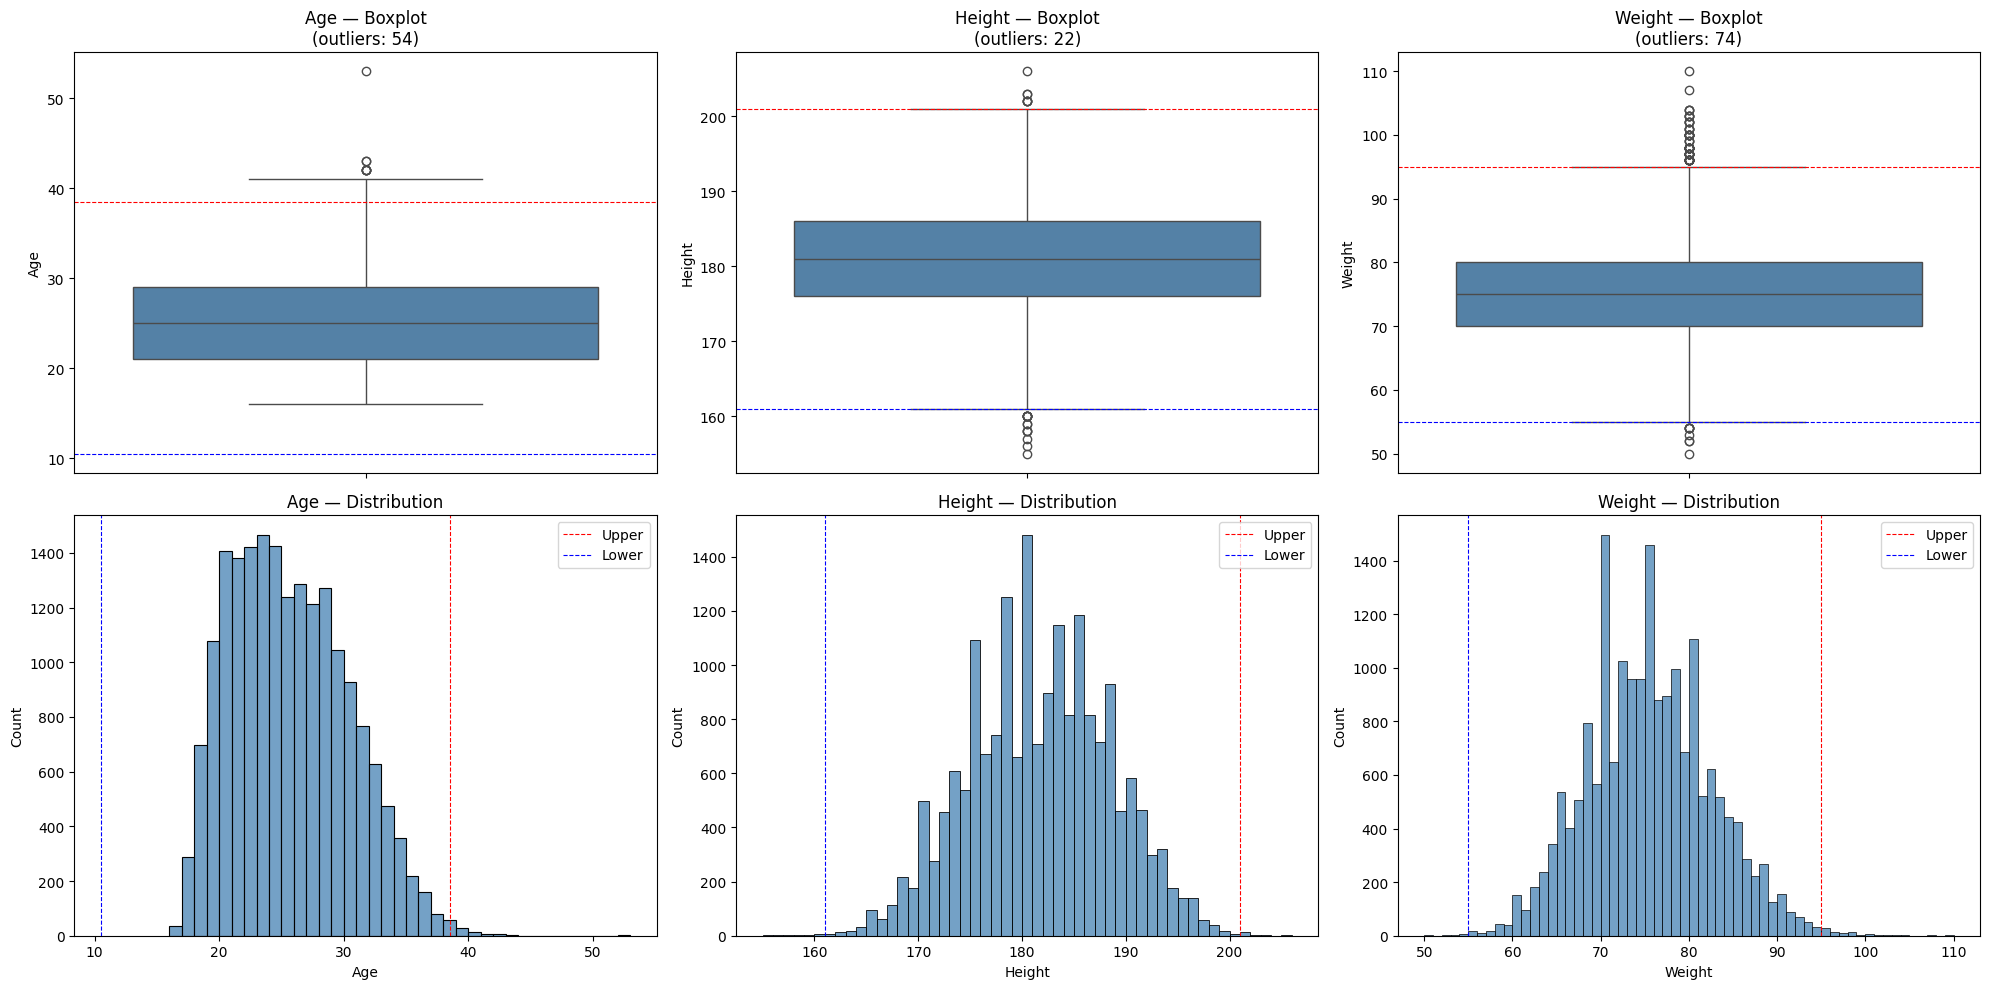

In [48]:
outlier_cols = ["Age", "Height", "Weight"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i, c in enumerate(outlier_cols):
    # IQR calculation — big data safe, runs distributed
    q1, q3 = fifa.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = fifa.filter((col(c) < lower) | (col(c) > upper)).count()

    # NOTE: .toPandas() only on single column for visualization
    col_pd = fifa.select(c).filter(col(c).isNotNull()).toPandas()

    # Boxplot
    sns.boxplot(y=col_pd[c], ax=axes[0][i], color="steelblue")
    axes[0][i].axhline(y=upper, color="red", linestyle="--", linewidth=0.8)
    axes[0][i].axhline(y=lower, color="blue", linestyle="--", linewidth=0.8)
    axes[0][i].set_title(f"{c} — Boxplot\n(outliers: {n_outliers})")
    axes[0][i].set_ylabel(c)

    # Histograma
    sns.histplot(col_pd[c], binwidth=1, ax=axes[1][i], color="steelblue")
    axes[1][i].axvline(x=upper, color="red", linestyle="--", linewidth=0.8, label="Upper")
    axes[1][i].axvline(x=lower, color="blue", linestyle="--", linewidth=0.8, label="Lower")
    axes[1][i].set_title(f"{c} — Distribution")
    axes[1][i].set_xlabel(c)
    axes[1][i].legend()

plt.tight_layout()
plt.show()

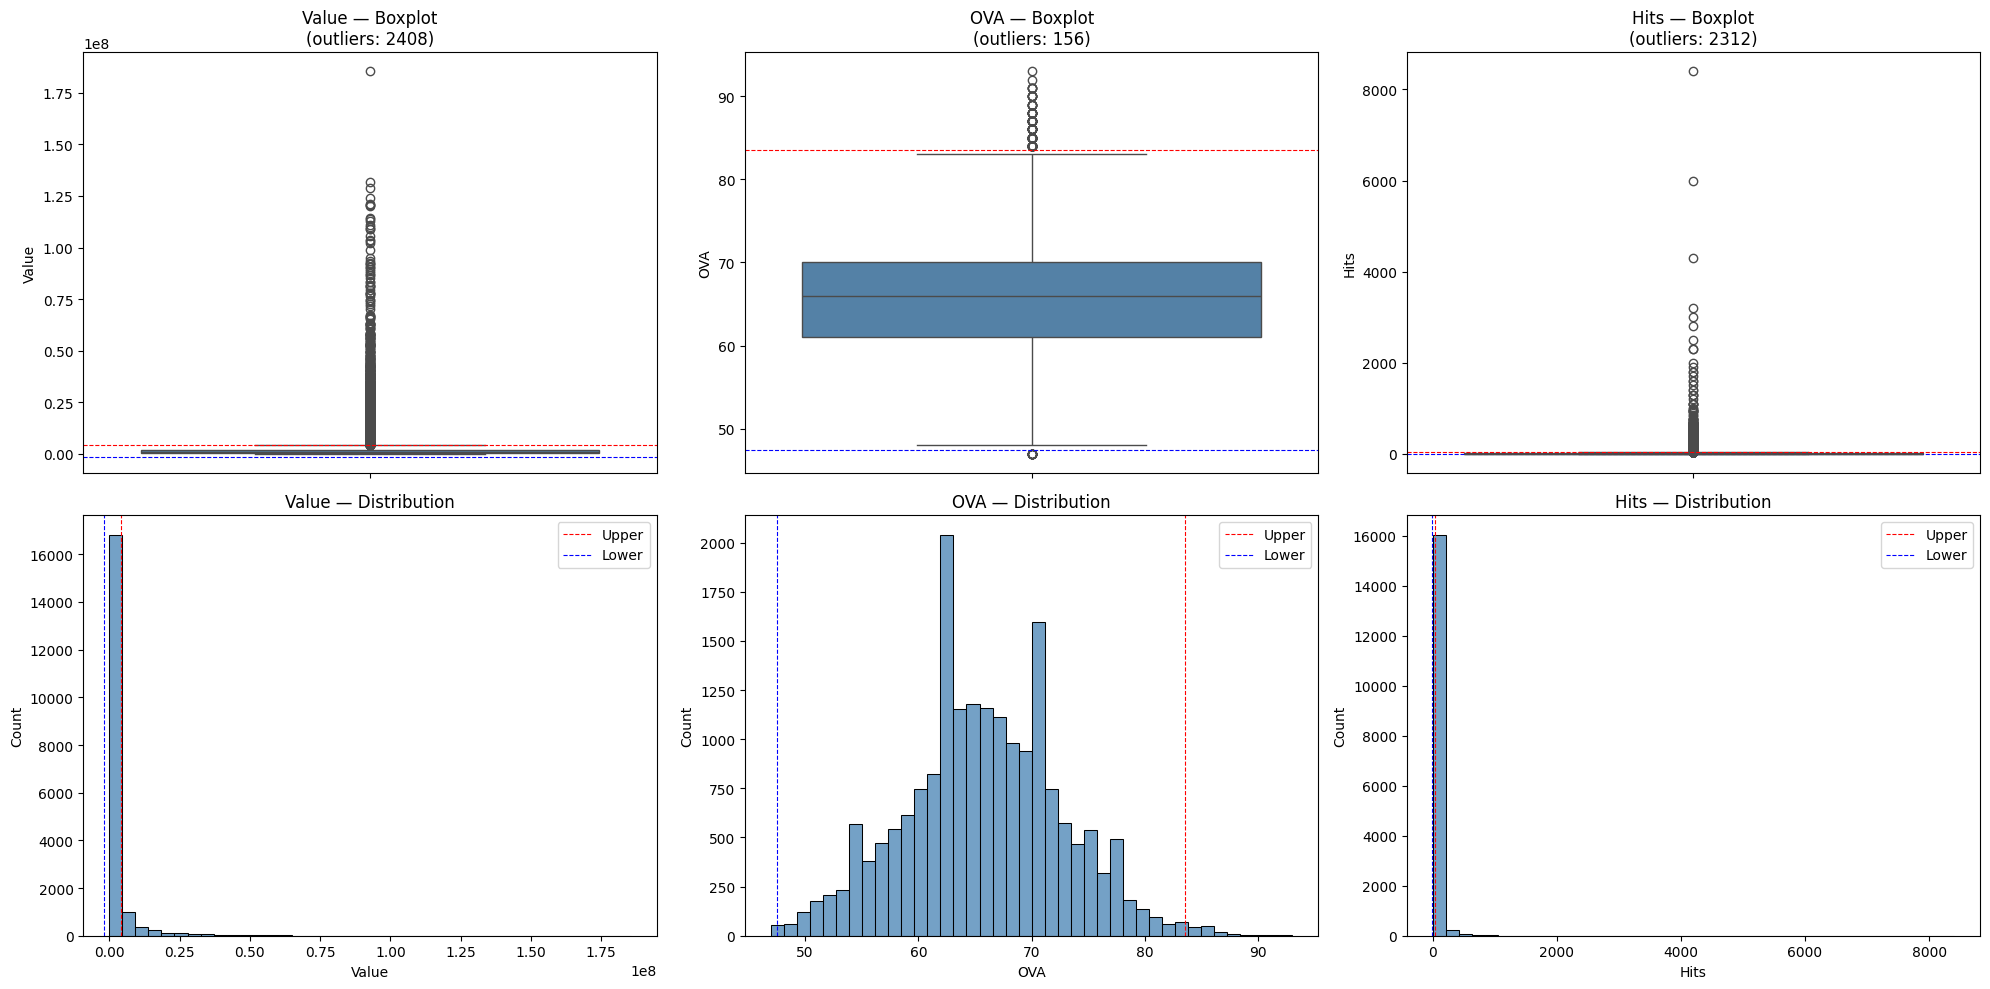

In [52]:
outlier_cols = ["Value", "OVA", "Hits"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i, c in enumerate(outlier_cols):
    # IQR calculation — big data safe, runs distributed
    q1, q3 = fifa.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = fifa.filter((col(c) < lower) | (col(c) > upper)).count()

    # NOTE: .toPandas() only on single column for visualization
    col_pd = fifa.select(c).filter(col(c).isNotNull()).toPandas()

    # Boxplot
    sns.boxplot(y=col_pd[c], ax=axes[0][i], color="steelblue")
    axes[0][i].axhline(y=upper, color="red", linestyle="--", linewidth=0.8)
    axes[0][i].axhline(y=lower, color="blue", linestyle="--", linewidth=0.8)
    axes[0][i].set_title(f"{c} — Boxplot\n(outliers: {n_outliers})")
    axes[0][i].set_ylabel(c)

    # Histograma
    sns.histplot(col_pd[c], bins=40, ax=axes[1][i], color="steelblue")
    axes[1][i].axvline(x=upper, color="red", linestyle="--", linewidth=0.8, label="Upper")
    axes[1][i].axvline(x=lower, color="blue", linestyle="--", linewidth=0.8, label="Lower")
    axes[1][i].set_title(f"{c} — Distribution")
    axes[1][i].set_xlabel(c)
    axes[1][i].legend()

plt.tight_layout()
plt.show()

**Correlations**

In [40]:
# features for correlation will be the ones w/o missing values and numeric. From numeric_cols we will remove "Hits" and "End_Loan_Date"
correlation_cols = [c for c in numeric_cols if c not in ["ID", "Hits", "End_Loan_Date"]]

In [41]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

correlation_cols = [c for c, t in fifa.dtypes if t in ('int','double','float','bigint')]

assembler = VectorAssembler(inputCols=correlation_cols, outputCol="features", handleInvalid="skip")
df_vec = assembler.transform(fifa).select("features")

corr_matrix = Correlation.corr(df_vec, "features", method="pearson").head()[0]
corr_array = corr_matrix.toArray()\

import plotly.express as px
import pandas as pd

corr_df = pd.DataFrame(corr_array, index=correlation_cols, columns=correlation_cols)

fig = px.imshow(
    corr_df,
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="Full Correlation Matrix",
)
fig.update_layout(width=1000, height=1000)
fig.show()

26/06/01 12:03:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


<a class="anchor" id="8">

# **8. Feature Engineering**

[Back to TOC](#toc)
</a>

A new feature engineered `N_Positions` to count the total playable positions per player, capturing their versatility.

In [42]:
fifa = fifa.withColumn("N_Positions", size(split(col("Positions"), ",")))

We engineered three new clean features (`Contract_Status`, `Contract_Start_Year`, and `Contract_End_Year`) to replace the messy raw data. The redundant `Contract`, `Joined`, and `Loan Date End` columns were dropped to keep the dataset clean.

In [43]:
# 1. Categorize contract status
fifa = fifa.withColumn("Contract_Status", 
    when(col("Contract").contains("On Loan"), "On Loan")
    .when(col("Contract").contains("Free"), "Free")
    .otherwise("Permanent")
)

# 2. Extract start year from 'Joined' (Null for 'Free' agents)
fifa = fifa.withColumn("Contract_Start_Year", 
    when(col("Contract_Status") == "Free", None)
    .otherwise(year(to_date(col("Joined"), "MMM d, yyyy")))
)

# 3. Extract end year based on status (Null for 'Free' agents)
fifa = fifa.withColumn("Contract_End_Year",
    when(col("Contract_Status") == "Permanent", trim(split(col("Contract"), "~")[1]).cast("int"))
    .when(col("Contract_Status") == "On Loan", regexp_extract(col("Contract"), r"(\d{4})", 1).cast("int"))
    .otherwise(None)
)

# 4. Drop redundant columns
fifa = fifa.drop("Contract", "Joined", "Loan Date End")

# Validate results
fifa.select("Name", "Contract_Status", "Contract_Start_Year", "Contract_End_Year").show(15, truncate=False)

+---------------------------------+---------------+-------------------+-----------------+
|Name                             |Contract_Status|Contract_Start_Year|Contract_End_Year|
+---------------------------------+---------------+-------------------+-----------------+
|Lionel Messi                     |Permanent      |2004               |2021             |
|C. Ronaldo dos Santos Aveiro     |Permanent      |2018               |2022             |
|Jan Oblak                        |Permanent      |2014               |2023             |
|Kevin De Bruyne                  |Permanent      |2015               |2023             |
|Neymar da Silva Santos Jr.       |Permanent      |2017               |2022             |
|Robert Lewandowski               |Permanent      |2014               |2023             |
|Mohamed Salah                    |Permanent      |2017               |2023             |
|Alisson Ramses Becker            |Permanent      |2018               |2024             |
|Kylian Mb

Loaned players, have Start_Year from original club and End_Year from loaned club

In [44]:
for col_name, dtype in fifa.dtypes:
    print(f"{col_name}: {dtype}")

ID: int
Name: string
Nationality: string
Age: int
OVA: int
POT: int
Club: string
Positions: string
Height: int
Weight: int
Preferred_Foot: string
BOV: int
Best_Position: string
Value: int
Wage: int
Release_Clause: int
Attacking: int
Crossing: int
Finishing: int
Heading_Accuracy: int
Short_Passing: int
Volleys: int
Skill: int
Dribbling: int
Curve: int
FK_Accuracy: int
Long_Passing: int
Ball_Control: int
Movement: int
Acceleration: int
Sprint_Speed: int
Agility: int
Reactions: int
Balance: int
Power: int
Shot_Power: int
Jumping: int
Stamina: int
Strength: int
Long_Shots: int
Mentality: int
Aggression: int
Interceptions: int
Positioning: int
Vision: int
Penalties: int
Composure: int
Defending: int
Marking: int
Standing_Tackle: int
Sliding_Tackle: int
Goalkeeping: int
GK_Diving: int
GK_Handling: int
GK_Kicking: int
GK_Positioning: int
GK_Reflexes: int
Total_Stats: int
Base_Stats: int
Weak_Foot: int
Skill_Moves: int
Attack_Workrate: string
Defense_Workrate: string
Intl_Reputation: int
PAC: 

In [45]:
fifa.write.mode("overwrite").parquet("cleaned_fifa.parquet")


Since we have so many columns, we will probably drop some if they have redundant information.


**To do**: depois de passar para num voltar a fazer describe,

visiluaziaçoes das distribuiçoes
-wage OK
-value ok
-hits Ok
-clubs ok
-nacionalidade ok
-tipo de contrato Ok
-idade ok
-preferred foot ok
-height?weight? ok
-total stats/base stats ok



Como o dataset infelizmente não tem uma coluna a dizer "Data de início do empréstimo", manter o ano do Joined continua a ser a melhor opção para não deixar o início a nulo, mas é um ótimo ponto para você escrever e explicar no seu notebook (em Markdown) demonstrando que percebeu a limitação dos dados!

In [ ]:
fifa.show()

+------+--------------------+-----------+---+---+---+-------------------+----------+------+------+--------------+---+-------------+---------+------+--------------+---------+--------+---------+----------------+-------------+-------+-----+---------+-----+-----------+------------+------------+--------+------------+------------+-------+---------+-------+-----+----------+-------+-------+--------+----------+---------+----------+-------------+-----------+------+---------+---------+---------+-------+---------------+--------------+-----------+---------+-----------+----------+--------------+-----------+-----------+----------+---------+-----------+---------------+----------------+---------------+---+---+---+---+---+---+----+-----------+---------------+-------------------+-----------------+
|    ID|                Name|Nationality|Age|OVA|POT|               Club| Positions|Height|Weight|Preferred_Foot|BOV|Best_Position|    Value|  Wage|Release_Clause|Attacking|Crossing|Finishing|Heading_Accuracy|S